# Inkference AR – TrOCR Fine-Tuning on Bentham R0 (Augmented)

Experiment 2: same setup as `inkference_ar.ipynb` but with data augmentation during training  
(random affine + Gaussian blur + sharpness jitter) to improve cross-domain generalisation.  
Checkpoint saved to `../checkpoints/best_aug/`.

## Step 1 – Understand the Dataset

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from pathlib import Path
import pandas as pd
from PIL import Image

ROOT      = Path("..")
GT_DIR    = ROOT / "data" / "BenthamDatasetR0-GT"
LINES_DIR = GT_DIR / "Images" / "Lines"
TRANS_DIR = GT_DIR / "Transcriptions"
PART_DIR  = GT_DIR / "Partitions"

print("Paths present:")
for p in [GT_DIR, LINES_DIR, TRANS_DIR, PART_DIR]:
    print(f"  {'✓' if p.exists() else '✗'} {p}")

Paths present:
  ✓ ../data/BenthamDatasetR0-GT
  ✓ ../data/BenthamDatasetR0-GT/Images/Lines
  ✓ ../data/BenthamDatasetR0-GT/Transcriptions
  ✓ ../data/BenthamDatasetR0-GT/Partitions


In [2]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
print(f"Random seed set to {SEED}")

Random seed set to 42


In [3]:
# Check number of samples per partition
for lst in ["TrainLines.lst", "ValidationLines.lst", "TestLines.lst"]:
    count = len((PART_DIR / lst).read_text().strip().splitlines())
    label = lst.replace("Lines.lst", "")
    print(f"{label:12s}: {count:>6} lines")

Train       :   9198 lines
Validation  :   1415 lines
Test        :    860 lines


In [4]:
# Sample: image size and mode (first 200 images)
img_files = sorted(LINES_DIR.glob("*.png"))[:200]
widths, heights, modes = [], [], set()

for f in img_files:
    img = Image.open(f)
    widths.append(img.size[0])
    heights.append(img.size[1])
    modes.add(img.mode)

print(f"Image modes : {modes}  → converted to RGB")
print(f"Width       : min={min(widths)}, max={max(widths)}, median={sorted(widths)[len(widths)//2]}")
print(f"Height      : min={min(heights)}, max={max(heights)}, median={sorted(heights)[len(heights)//2]}")

Image modes : {'RGBA'}  → converted to RGB
Width       : min=49, max=2311, median=1631
Height      : min=28, max=385, median=157


## Step 2 – Link Image-Transcript Pairs

Each image in `Images/Lines/` has a matching `.txt` file in `Transcriptions/`.  
We build a DataFrame with `image_path` and `transcription`.

In [5]:
records = []
for img_path in sorted(LINES_DIR.glob("*.png")):
    trans_path = TRANS_DIR / f"{img_path.stem}.txt"
    if trans_path.exists():
        transcription = trans_path.read_text(encoding="utf-8").strip()
        records.append({"image_path": str(img_path), "transcription": transcription})

df = pd.DataFrame(records)
print(f"Total pairs: {len(df)}")
df.head(10)

Total pairs: 11473


,image_path,transcription
0,../data/BenthamDatasetR0-GT/Images/Lines/002_0...,36
1,../data/BenthamDatasetR0-GT/Images/Lines/002_0...,16 Aug 1800
2,../data/BenthamDatasetR0-GT/Images/Lines/002_0...,"6 . The evidence of the engagement , consigned..."
3,../data/BenthamDatasetR0-GT/Images/Lines/002_0...,"instrument , instead of a fixed Book . _ Tak..."
4,../data/BenthamDatasetR0-GT/Images/Lines/002_0...,"quer Bills , _ Differs from Stock Annuities ..."
5,../data/BenthamDatasetR0-GT/Images/Lines/002_0...,"Irish Debentures , and the now disused Navy Vi..."
6,../data/BenthamDatasetR0-GT/Images/Lines/002_0...,alling Transport and Ordnance Bills or Debentu...
7,../data/BenthamDatasetR0-GT/Images/Lines/002_0...,"also with India Bonds , Bank Notes , Banker ' ..."
8,../data/BenthamDatasetR0-GT/Images/Lines/002_0...,Notes ; and private Promissory Notes and Bills...
9,../data/BenthamDatasetR0-GT/Images/Lines/002_0...,"7 . The Paper , by its size , shape , texture ..."


## Step 3 – Load & Split Partitions

The `.lst` files in `Partitions/` determine which lines belong to train, validation, and test.

In [6]:
def load_ids(lst_file):
    return set(Path(lst_file).read_text().strip().splitlines())

train_ids = load_ids(PART_DIR / "TrainLines.lst")
val_ids   = load_ids(PART_DIR / "ValidationLines.lst")
test_ids  = load_ids(PART_DIR / "TestLines.lst")

def assign_split(image_path):
    stem = Path(image_path).stem
    if stem in train_ids: return "train"
    if stem in val_ids:   return "val"
    if stem in test_ids:  return "test"
    return "unknown"

df["split"] = df["image_path"].apply(assign_split)

print(df["split"].value_counts().to_string())
print(f"\nUnknown entries: {(df['split'] == 'unknown').sum()}")

split
train    9198
val      1415
test      860

Unknown entries: 0


In [7]:
df_train = df[df["split"] == "train"].reset_index(drop=True)
df_val   = df[df["split"] == "val"].reset_index(drop=True)
df_test  = df[df["split"] == "test"].reset_index(drop=True)

print(f"Train : {len(df_train):>5} lines")
print(f"Val   : {len(df_val):>5} lines")
print(f"Test  : {len(df_test):>5} lines")

Train :  9198 lines
Val   :  1415 lines
Test  :   860 lines


## Step 4 – Preprocess Images

Images are in RGBA format. TrOCR expects RGB (3 channels).  
Resize (384 × 384) and normalisation are handled automatically by the `TrOCRProcessor`.

In [8]:
def load_image(image_path: str) -> Image.Image:
    """Load image and convert RGBA to RGB."""
    img = Image.open(image_path)
    if img.mode != "RGB":
        img = img.convert("RGB")
    return img

# Sanity check
sample_path = df_train.iloc[0]["image_path"]
img = load_image(sample_path)
print(f"Mode after conversion : {img.mode}")
print(f"Size (original)       : {img.size}")

Mode after conversion : RGB
Size (original)       : (85, 71)


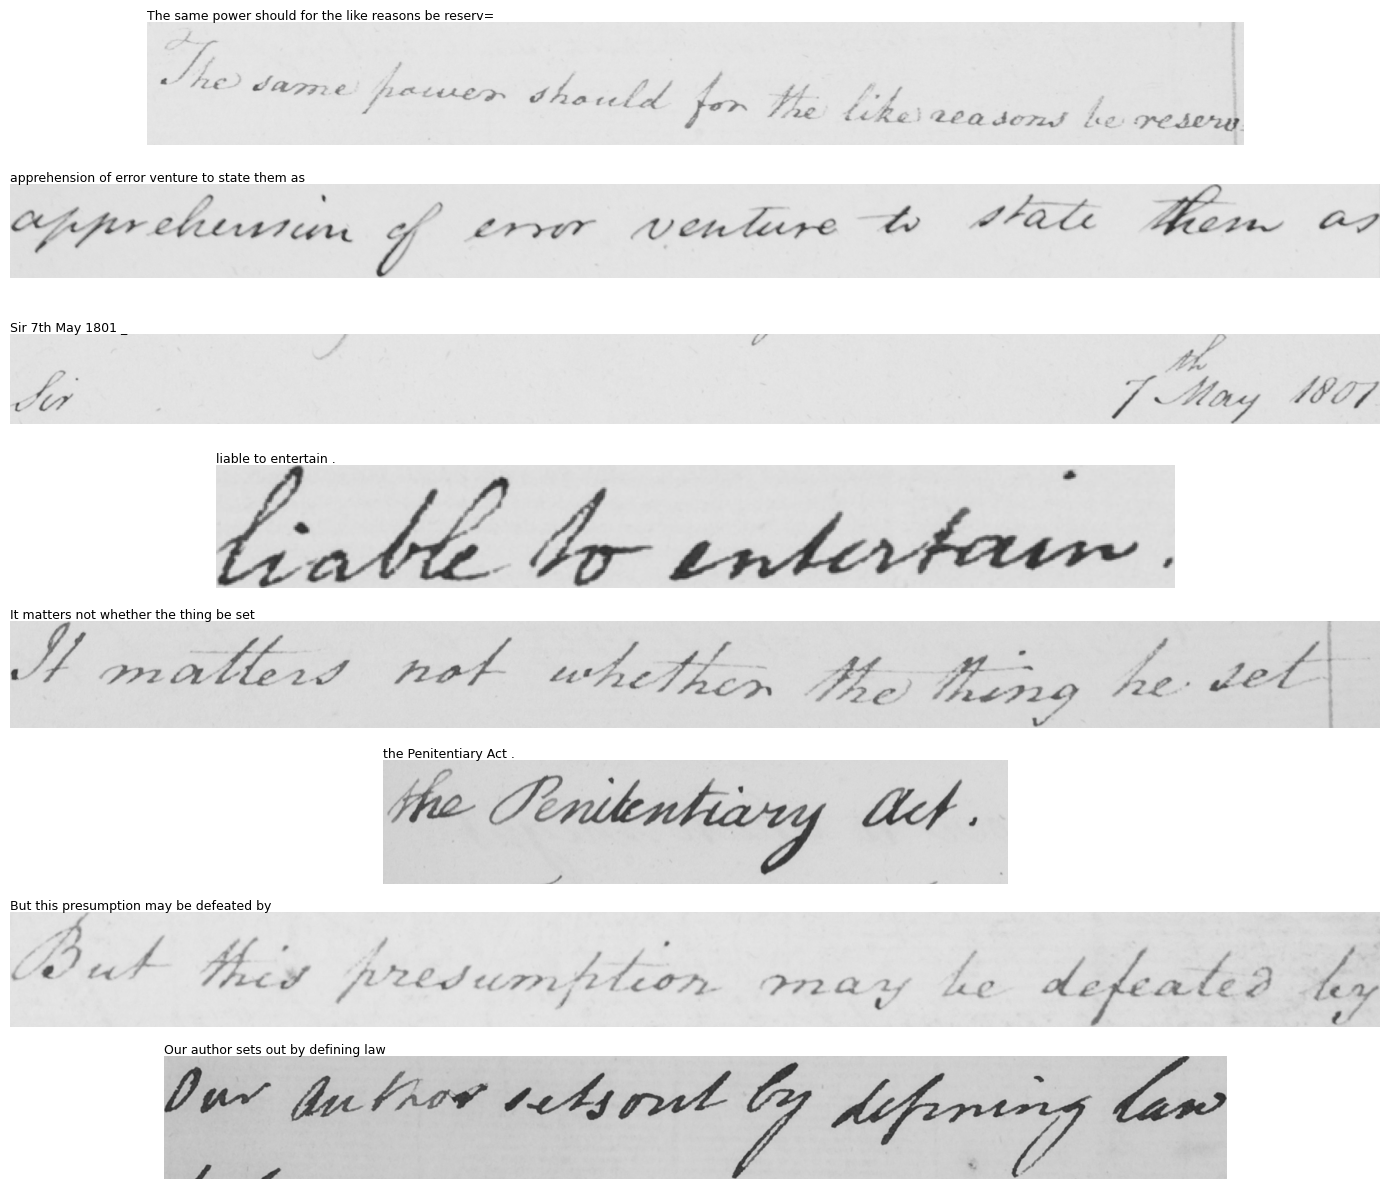

In [9]:
import matplotlib.pyplot as plt

# Visualise 8 random training lines
sample = df_train.sample(8, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(8, 1, figsize=(14, 12))
for ax, (_, row) in zip(axes, sample.iterrows()):
    img = load_image(row["image_path"])
    ax.imshow(img)
    ax.set_title(row["transcription"], fontsize=9, loc="left", pad=2)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Step 5 – Build Dataset Object

Two dataset classes:
- `BenthamDataset` — base class, no augmentation (used for val/test)
- `BenthamDatasetAug` — subclass with random affine + blur + sharpness jitter (**training only**)

Augmentation is applied only during training to prevent the model from memorising  
Bentham's exact style, improving generalisation to unseen handwriting.

In [10]:
from transformers import TrOCRProcessor

# Loads ViT-ImageProcessor + Tokenizer in one step
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
print("Processor loaded.")

/home/justin/Ginger_Gradient/14/project/Capstone-Project/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Processor loaded.


In [11]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class BenthamDataset(Dataset):
    def __init__(self, df, processor, max_target_length=128):
        self.df = df
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image and preprocess (resize + normalisation)
        img = load_image(row["image_path"])
        pixel_values = self.processor(images=img, return_tensors="pt").pixel_values.squeeze(0)

        # Tokenise transcription
        labels = self.processor.tokenizer(
            row["transcription"],
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True,
            return_tensors="pt",
        ).input_ids.squeeze(0)

        # Replace padding token IDs with -100 → ignored in Cross-Entropy Loss
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {"pixel_values": pixel_values, "labels": labels}


# Augmentation pipeline applied only during training
_aug = transforms.Compose([
    transforms.RandomAffine(degrees=2, translate=(0.02, 0.02), scale=(0.95, 1.05)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
])

class BenthamDatasetAug(BenthamDataset):
    """BenthamDataset with random augmentation applied before the TrOCR processor."""
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = load_image(row["image_path"])
        img = _aug(img)   # augment before processor
        pixel_values = self.processor(images=img, return_tensors="pt").pixel_values.squeeze(0)
        labels = self.processor.tokenizer(
            row["transcription"],
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True,
            return_tensors="pt",
        ).input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {"pixel_values": pixel_values, "labels": labels}

In [12]:
# Training uses augmented dataset; val/test use base dataset (no augmentation at eval time)
train_dataset = BenthamDatasetAug(df_train, processor)
val_dataset   = BenthamDataset(df_val,   processor)
test_dataset  = BenthamDataset(df_test,  processor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print(f"Batch pixel_values : {batch['pixel_values'].shape}")  # (16, 3, 384, 384)
print(f"Batch labels       : {batch['labels'].shape}")        # (16, 128)
print("DataLoader OK.")

Batch pixel_values : torch.Size([16, 3, 384, 384])
Batch labels       : torch.Size([16, 128])
DataLoader OK.


## Step 6 – Load & Configure TrOCR

- Model: `microsoft/trocr-base-handwritten` (pre-trained on handwriting)
- Optimizer: AdamW with LR 1e-5
- Scheduler: Linear Warmup (first 10% of steps) → then linear decay

In [13]:
from transformers import VisionEncoderDecoderModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")

# Decoder configuration
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.eos_token_id           = processor.tokenizer.sep_token_id

# Gradient checkpointing: saves ~60-70% VRAM at the cost of ~20% longer training time
model.config.use_cache = False
model.gradient_checkpointing_enable()

model.to(device)
print("Model loaded. Gradient checkpointing active.")

Device: cuda


/home/justin/Ginger_Gradient/14/project/Capstone-Project/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded. Gradient checkpointing active.


In [14]:
from torch.optim import AdamW
from transformers import get_scheduler

EPOCHS        = 30
LEARNING_RATE = 1e-5   # reduced from 5e-5: model is pre-trained and already performs well
WARMUP_RATIO  = 0.1

total_steps  = EPOCHS * len(train_loader)
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total training steps : {total_steps}")
print(f"Warmup steps         : {warmup_steps}")
print(f"Optimizer            : AdamW, LR={LEARNING_RATE}")
print(f"Scheduler            : Linear Warmup → Linear Decay")

Total training steps : 17250
Warmup steps         : 1725
Optimizer            : AdamW, LR=1e-05
Scheduler            : Linear Warmup → Linear Decay


## Step 7 – Training Loop

Per epoch: train → measure validation CER → save checkpoint → check early stopping.  
Patience = 3 epochs without improvement in validation CER.

In [15]:
import evaluate

cer_metric = evaluate.load("cer")

def compute_cer(model, dataloader, processor, device):
    """Compute CER on a dataloader split."""
    model.eval()
    all_preds, all_refs = [], []

    with torch.no_grad():
        for batch in dataloader:
            pixel_values = batch["pixel_values"].to(device)
            labels        = batch["labels"].clone()

            generated_ids = model.generate(pixel_values, max_new_tokens=128)
            preds = processor.batch_decode(generated_ids, skip_special_tokens=True)

            labels[labels == -100] = processor.tokenizer.pad_token_id
            refs = processor.batch_decode(labels, skip_special_tokens=True)

            all_preds.extend(preds)
            all_refs.extend(refs)

    return cer_metric.compute(predictions=all_preds, references=all_refs)

In [16]:
from tqdm.notebook import tqdm

PATIENCE       = 3
CHECKPOINT_DIR = Path("../checkpoints/best_aug")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

best_cer         = float("inf")
patience_counter = 0
history          = []
scaler           = torch.amp.GradScaler("cuda")

if torch.cuda.is_available():
    torch.cuda.empty_cache()

for epoch in range(1, EPOCHS + 1):

    # ── Training ────────────────────────────────────────────────────────────
    model.train()
    total_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS} [train]", leave=False):
        pixel_values = batch["pixel_values"].to(device)
        labels       = batch["labels"].to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = model(pixel_values=pixel_values, labels=labels)

        scaler.scale(outputs.loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += outputs.loss.item()

    avg_loss = total_loss / len(train_loader)

    # ── Validation CER ──────────────────────────────────────────────────────
    val_cer = compute_cer(model, val_loader, processor, device)

    history.append({"epoch": epoch, "train_loss": avg_loss, "val_cer": val_cer})
    print(f"Epoch {epoch:02d} | Loss: {avg_loss:.4f} | Val CER: {val_cer:.4f}", end="")

    # ── Checkpoint & Early Stopping ─────────────────────────────────────────
    if val_cer < best_cer:
        best_cer         = val_cer
        patience_counter = 0
        model.save_pretrained(CHECKPOINT_DIR)
        processor.save_pretrained(CHECKPOINT_DIR)
        print(f"  ✓ Best model saved")
    else:
        patience_counter += 1
        print(f"  ✗ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping after epoch {epoch} — best Val CER: {best_cer:.4f}")
            break

Epoch 01/30 [train]:   0%|          | 0/575 [00:00<?, ?it/s]

Epoch 01 | Loss: 2.5594 | Val CER: 0.0881  ✓ Best model saved


Epoch 02/30 [train]:   0%|          | 0/575 [00:00<?, ?it/s]

Epoch 02 | Loss: 0.7428 | Val CER: 0.0589  ✓ Best model saved


Epoch 03/30 [train]:   0%|          | 0/575 [00:00<?, ?it/s]

...

Epoch 07 | Loss: 0.2404 | Val CER: 0.0446  ✗ No improvement (1/3)


Epoch 08/30 [train]:   0%|          | 0/575 [00:00<?, ?it/s]

Epoch 08 | Loss: 0.3393 | Val CER: 0.0450  ✗ No improvement (2/3)


Epoch 09/30 [train]:   0%|          | 0/575 [00:00<?, ?it/s]

Epoch 09 | Loss: 0.2066 | Val CER: 0.0453  ✗ No improvement (3/3)

Early stopping after epoch 9 — best Val CER: 0.0441


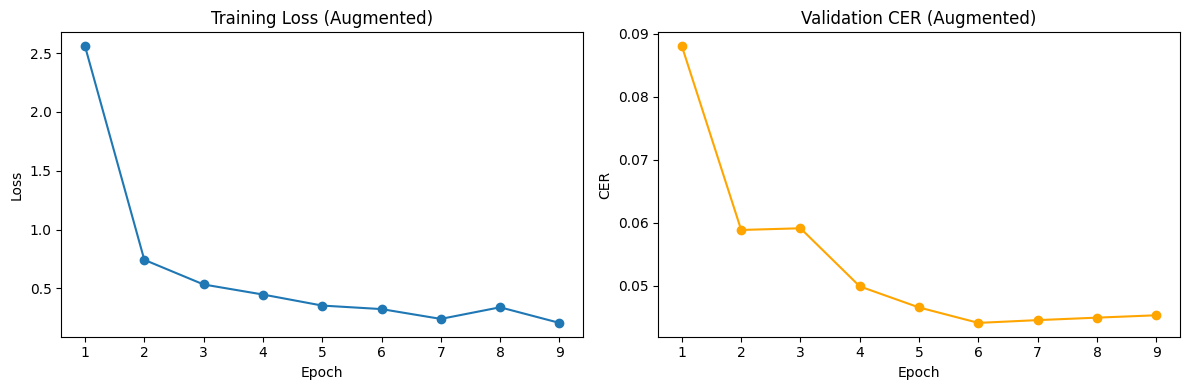


Best Validation CER: 0.0441 (Epoch 6)


In [17]:
# Learning curve after training
history_df = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_df["epoch"], history_df["train_loss"], marker="o")
ax1.set_title("Training Loss (Augmented)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2.plot(history_df["epoch"], history_df["val_cer"], marker="o", color="orange")
ax2.set_title("Validation CER (Augmented)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("CER")

plt.tight_layout()
plt.show()
print(f"\nBest Validation CER: {history_df['val_cer'].min():.4f} (Epoch {history_df['val_cer'].idxmin() + 1})")

## Step 8 – Evaluation

Load best checkpoint → CER & WER on the test set (quantitative) → sample predictions (qualitative).  
This cell is self-contained and can be run after a kernel restart without retraining.

In [18]:
import torch
import evaluate
from pathlib import Path
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
from transformers import VisionEncoderDecoderModel, TrOCRProcessor

device         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_DIR = Path("../checkpoints/best_aug")
cer_metric     = evaluate.load("cer")

# Load best augmented checkpoint
best_model     = VisionEncoderDecoderModel.from_pretrained(CHECKPOINT_DIR).to(device)
best_processor = TrOCRProcessor.from_pretrained(CHECKPOINT_DIR)
best_model.eval()
print(f"Device     : {device}")
print(f"Checkpoint : {CHECKPOINT_DIR}")

Device     : cuda
Checkpoint : ../checkpoints/best_aug


In [19]:
wer_metric = evaluate.load("wer")

def compute_metrics(model, processor, df_split, device, batch_size=16):
    """Return CER, WER and all predictions."""
    dataset    = BenthamDataset(df_split, processor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    all_preds, all_refs = [], []
    model.eval()

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            pixel_values = batch["pixel_values"].to(device)
            labels       = batch["labels"].clone()

            generated_ids = model.generate(pixel_values, max_new_tokens=128)
            preds = processor.batch_decode(generated_ids, skip_special_tokens=True)

            labels[labels == -100] = processor.tokenizer.pad_token_id
            refs = processor.batch_decode(labels, skip_special_tokens=True)

            all_preds.extend(preds)
            all_refs.extend(refs)

    cer = cer_metric.compute(predictions=all_preds, references=all_refs)
    wer = wer_metric.compute(predictions=all_preds, references=all_refs)
    return cer, wer, all_preds, all_refs

test_cer, test_wer, test_preds, test_refs = compute_metrics(
    best_model, best_processor, df_test, device
)

print(f"Test CER : {test_cer:.4f}  ({test_cer*100:.2f}%)")
print(f"Test WER : {test_wer:.4f}  ({test_wer*100:.2f}%)")

Evaluating:   0%|          | 0/54 [00:00<?, ?it/s]

Test CER : 0.0451  (4.51%)
Test WER : 0.1678  (16.78%)


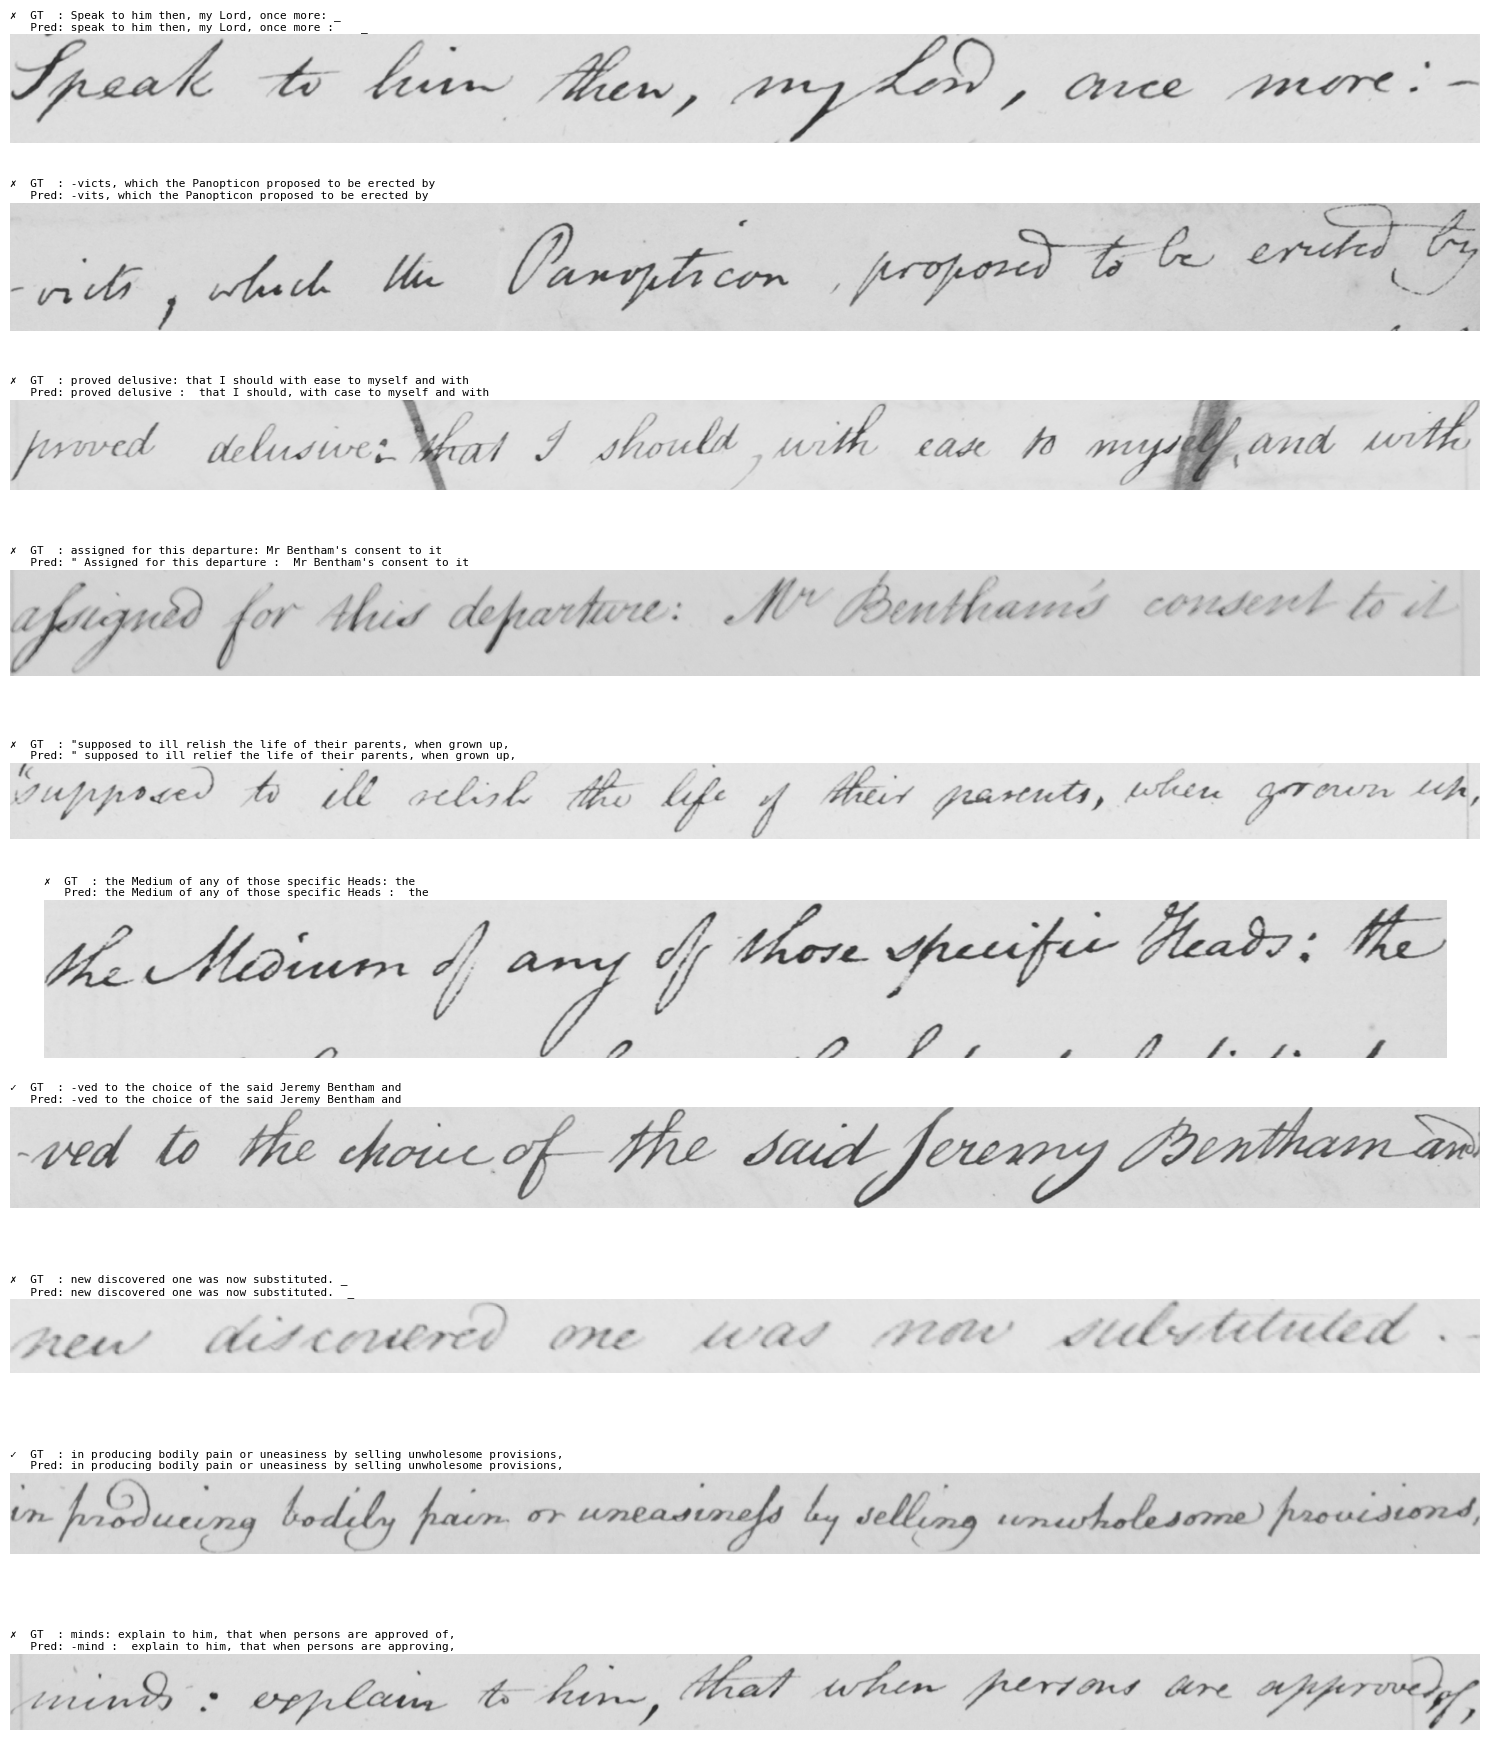

In [20]:
# Qualitative examples: 10 random test lines with image, prediction and ground truth
sample_idx = df_test.sample(10, random_state=7).index.tolist()

fig, axes = plt.subplots(10, 1, figsize=(15, 18))
for ax, idx in zip(axes, sample_idx):
    img  = load_image(df_test.iloc[idx]["image_path"])
    pred = test_preds[idx]
    ref  = test_refs[idx]
    match = "✓" if pred.strip() == ref.strip() else "✗"
    ax.imshow(img)
    ax.set_title(
        f"{match}  GT  : {ref}\n   Pred: {pred}",
        fontsize=8, loc="left", pad=3, family="monospace"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [21]:
# Error analysis: the 10 worst lines (highest character error)
from jiwer import cer as line_cer

errors = []
for idx, (pred, ref) in enumerate(zip(test_preds, test_refs)):
    if ref.strip():
        c = line_cer(ref, pred)
        errors.append((c, idx, ref, pred))

errors.sort(reverse=True)
print("10 worst predictions:\n")
for c, idx, ref, pred in errors[:10]:
    print(f"  CER {c:.2f} | GT  : {ref}")
    print(f"          | Pred: {pred}")
    print()

10 worst predictions:

  CER 2.00 | GT  : 2
          | Pred: 58

  CER 2.00 | GT  : a
          | Pred: of

  CER 2.00 | GT  : B
          | Pred: 13

  CER 1.50 | GT  : (4
          | Pred: ( 4 )

  CER 1.20 | GT  : under
          | Pred: unctes  _

  CER 1.00 | GT  : 7
          | Pred: 1

  CER 1.00 | GT  : 9
          | Pred: 2

  CER 1.00 | GT  : 107
          | Pred: For

  CER 1.00 | GT  : e
          | Pred: 6

  CER 1.00 | GT  : (A)
          | Pred: 4

